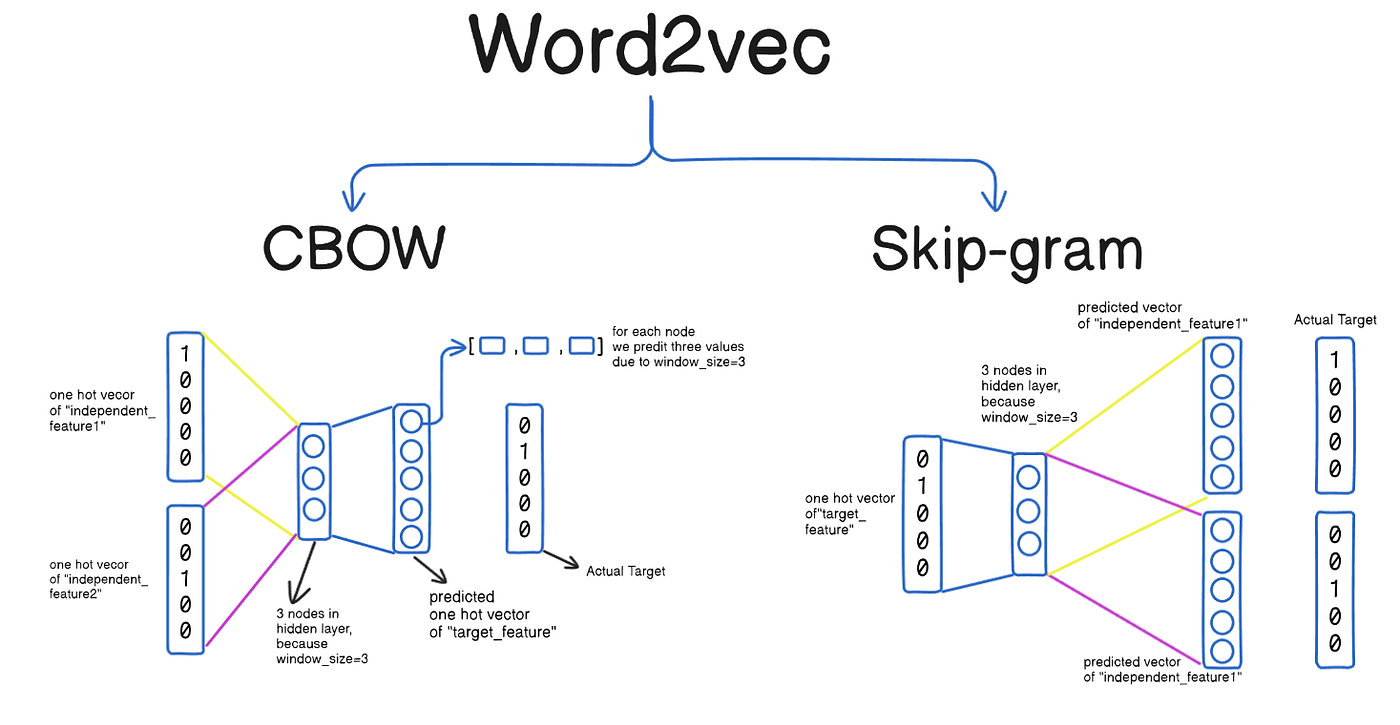

## Word2Vec

Word2Vec is a **word embedding technique** used to represent words as **dense vectors** of real numbers. Unlike older frequency-based methods like Bag of Words or TF-IDF, Word2Vec captures the **semantic meaning** and context of words, allowing machines to understand the relationships between them based on proximity in a high-dimensional space.

### Core Intuition: Semantic Meaning

The underlying principle is that words sharing **similar contexts** have **similar meanings** and therefore similar vector representations. For example, in a large corpus, _football_ and _hockey_ are likely to appear near similar surrounding words, leading the model to place their vectors close together.

### Word2Vec Architectures

Word2Vec utilizes two main **neural network** architectures to learn these representations:

1. **Continuous Bag of Words (CBOW):** This architecture predicts a **target word** based on its surrounding **context words**.
2. **Skip-gram:** This architecture takes a single **target word** and predicts the surrounding **context words**.

### Key Benefits

- **Dense Representations:** Vectors are compact and efficient compared to sparse, high-dimensional frequency matrices.
- **Semantic Relationships:** The model can capture complex relationships, such as gender or verb tense, allowing for vector arithmetic (e.g., _King - Man + Woman = Queen_).

In [1]:
import numpy as np
import pandas as pd

In [8]:
import gensim
import os

In [ ]:
import nltk

nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/slayer0x10/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [15]:
from nltk import sent_tokenize
from gensim.utils import simple_preprocess

story = []
for filename in os.listdir("got-data"):
    f = open(os.path.join("got-data", filename), encoding="cp1252")
    corpus = f.read()

    raw_sent = sent_tokenize(corpus)
    for sent in raw_sent:
        story.append(simple_preprocess(sent))

In [16]:
len(story)

145020

In [20]:
model = gensim.models.Word2Vec(window=10, min_count=2, workers=10)
model.build_vocab(story)

In [21]:
model.train(story, total_examples=model.corpus_count, epochs=model.epochs)

(6570281, 8628190)

In [27]:
model.wv.most_similar("duncan")

[('bayard', 0.9607111215591431),
 ('turnberry', 0.9440076947212219),
 ('hugh', 0.9389026165008545),
 ('danwell', 0.9209336042404175),
 ('clifton', 0.9206610321998596),
 ('mullendore', 0.9200802445411682),
 ('hugo', 0.9192653298377991),
 ('dafyn', 0.917409360408783),
 ('greenfield', 0.9167826175689697),
 ('giantslayer', 0.9153052568435669)]

In [29]:
model.wv["duncan"].size

100

---